# Fraud Detection Model Explainability

This notebook explains the Random Forest fraud detection model using SHAP.

Objectives:
- Analyze global feature importance
- Explain individual predictions
- Generate business recommendations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv(
    "../data/processed/fraud_model_ready.csv"
)

In [3]:
X = df.drop(
    "class",
    axis=1
)

y = df["class"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
model = joblib.load("../models/best_fraud_random_forest.pkl")

In [7]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [8]:
from sklearn.metrics import confusion_matrix

In [9]:
X_test.shape

(30223, 203)

In [10]:
import os

os.listdir("../models")

['best_fraud_random_forest.pkl', 'fraud_encoder.pkl', 'fraud_scaler.pkl']

In [11]:
model

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [12]:
feature_importance.head(10)

,Feature,Importance
8,device_transaction_count,0.400517
6,time_since_signup_hours,0.229398
4,purchase_month,0.165530
186,country_United States,0.020437
15,sex_M,0.018689
10,source_SEO,0.017898
12,browser_IE,0.017577
9,source_Direct,0.012487
14,browser_Safari,0.011566
11,browser_FireFox,0.010918


In [13]:
feature_importance.to_csv(
    "../data/processed/feature_importance_shap.csv",
    index=False
)

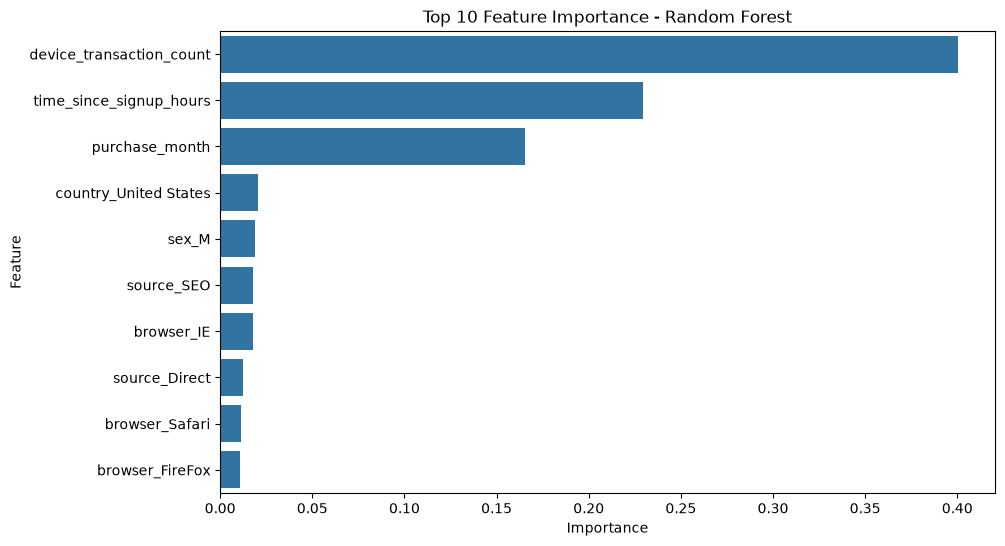

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importance - Random Forest"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.show()

In [15]:
X_sample = X_test.sample(
    n=500,
    random_state=42
)

In [16]:
X_sample.shape

(500, 203)

In [17]:
explainer = shap.TreeExplainer(
    model
)

In [18]:
shap_values = explainer(
    X_sample
)

In [19]:
type(shap_values)

shap._explanation.Explanation

In [20]:
shap_values.shape

(500, 203, 2)

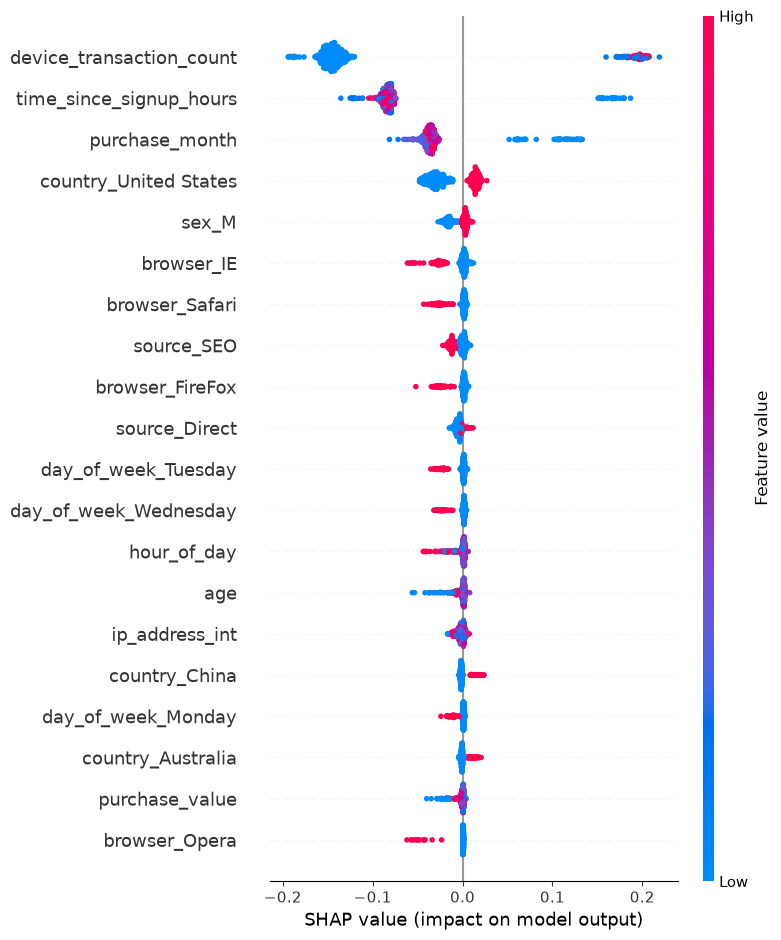

In [21]:
shap.summary_plot(
    shap_values[:,:,1],
    X_sample
)

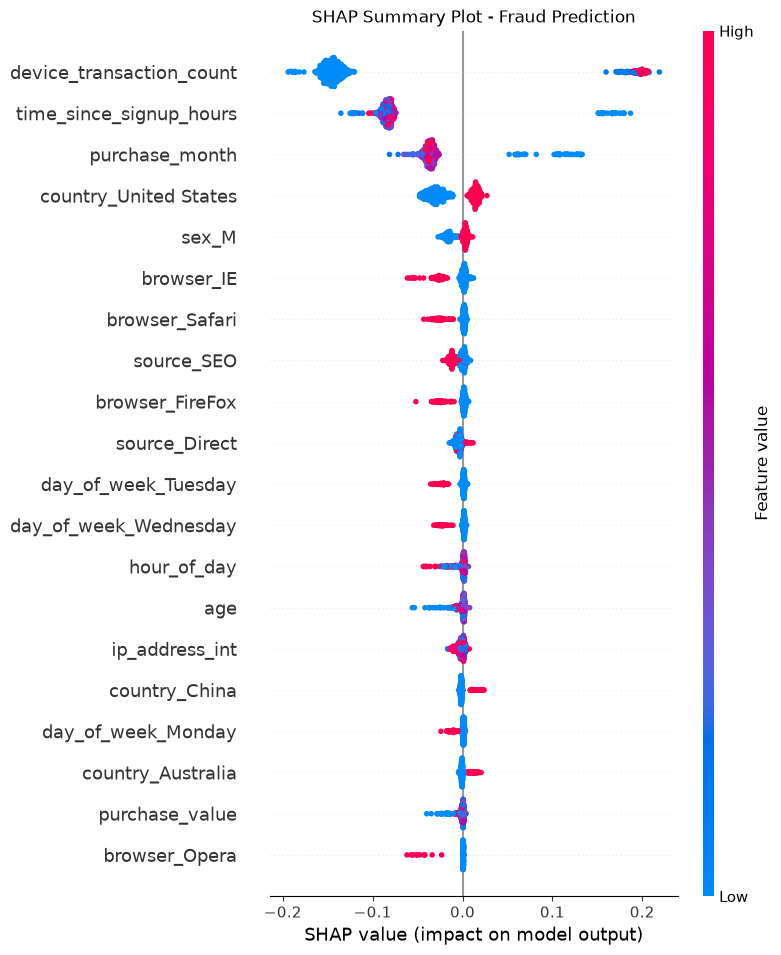

In [22]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values[:,:,1],
    X_sample,
    show=False
)

plt.title(
    "SHAP Summary Plot - Fraud Prediction"
)

plt.savefig(
    "../data/processed/shap_summary_plot.png",
    bbox_inches="tight"
)

plt.show()

In [23]:
y_pred = model.predict(X_test)

In [24]:
results = X_test.copy()

results["actual"] = y_test.values

results["predicted"] = y_pred

results.head()

,purchase_value,age,ip_address_int,hour_of_day,purchase_month,is_weekend,time_since_signup_hours,user_transaction_count,device_transaction_count,source_Direct,...,country_Zambia,country_Zimbabwe,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,actual,predicted
80016,-0.651398,-0.596528,0.100068,-1.088122,-0.003243,-0.637464,0.795000,0.0,-0.261514,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
117484,-0.160204,-1.060689,0.972271,-0.220124,1.124310,1.568716,1.236596,0.0,-0.261514,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
137399,2.514074,-1.408809,1.411791,1.226541,-0.379095,-0.637464,0.818311,0.0,0.120611,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1,0
93712,-0.705975,1.956356,0.420571,-0.798789,-0.379095,1.568716,-0.903077,0.0,-0.261514,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0
82814,0.221836,-0.596528,0.163407,0.213876,0.748459,-0.637464,1.309524,0.0,-0.261514,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0


In [25]:
true_positive = results[
    (results["actual"] == 1) &
    (results["predicted"] == 1)
]

In [26]:
false_positive = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

In [27]:
false_negative = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

In [28]:
print("True Positives:", len(true_positive))
print("False Positives:", len(false_positive))
print("False Negatives:", len(false_negative))

True Positives: 1720
False Positives: 811
False Negatives: 1110


In [29]:
tp_sample = true_positive.iloc[[0]]
fp_sample = false_positive.iloc[[0]]
fn_sample = false_negative.iloc[[0]]

In [30]:
tp_sample.shape, fp_sample.shape, fn_sample.shape

((1, 205), (1, 205), (1, 205))

In [31]:
tp_features = tp_sample.drop(
    columns=["actual", "predicted"]
)

fp_features = fp_sample.drop(
    columns=["actual", "predicted"]
)

fn_features = fn_sample.drop(
    columns=["actual", "predicted"]
)

In [32]:
tp_shap = explainer(tp_features)

fp_shap = explainer(fp_features)

fn_shap = explainer(fn_features)

In [34]:
shap.initjs()

In [35]:
shap.plots.force(
    tp_shap[:,:,1]
)

In [36]:
shap.plots.force(
    fp_shap[:,:,1]
)

In [37]:
shap.plots.force(
    fn_shap[:,:,1]
)

In [38]:
shap.save_html(
    "../data/processed/shap_true_positive.html",
    shap.plots.force(tp_shap[:,:,1], matplotlib=False)
)

In [39]:
shap.save_html(
    "../data/processed/shap_false_positive.html",
    shap.plots.force(fp_shap[:,:,1], matplotlib=False)
)

In [40]:
shap.save_html(
    "../data/processed/shap_false_negative.html",
    shap.plots.force(fn_shap[:,:,1], matplotlib=False)
)

In [41]:
mean_shap = np.abs(
    shap_values[:,:,1].values
).mean(axis=0)

In [42]:
shap_importance = pd.DataFrame(
    {
        "Feature": X_sample.columns,
        "SHAP Importance": mean_shap
    }
)

shap_importance = shap_importance.sort_values(
    by="SHAP Importance",
    ascending=False
)

In [43]:
shap_importance.head(5)

,Feature,SHAP Importance
8,device_transaction_count,0.152245
6,time_since_signup_hours,0.088962
4,purchase_month,0.042154
186,country_United States,0.024373
15,sex_M,0.008288


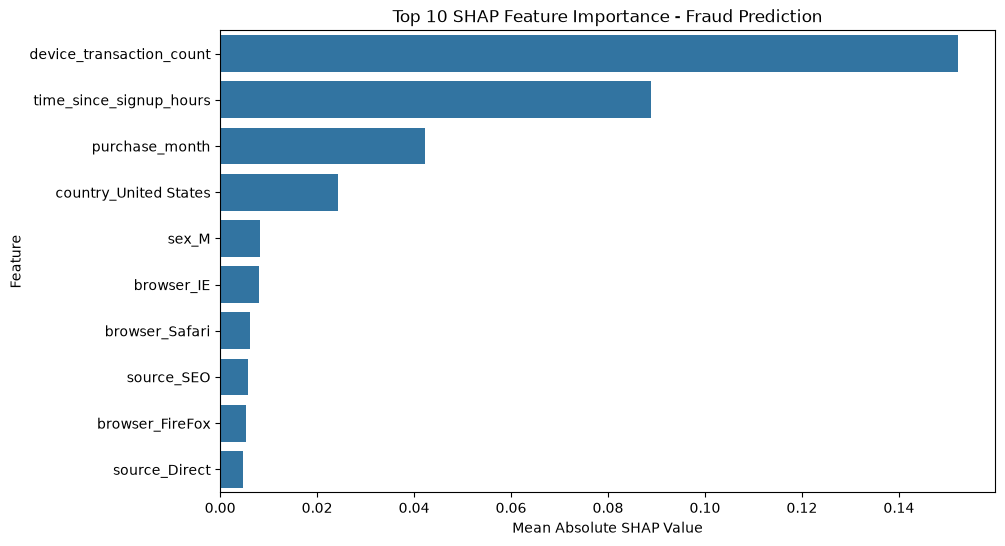

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=shap_importance.head(10),
    x="SHAP Importance",
    y="Feature"
)

plt.title(
    "Top 10 SHAP Feature Importance - Fraud Prediction"
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.show()

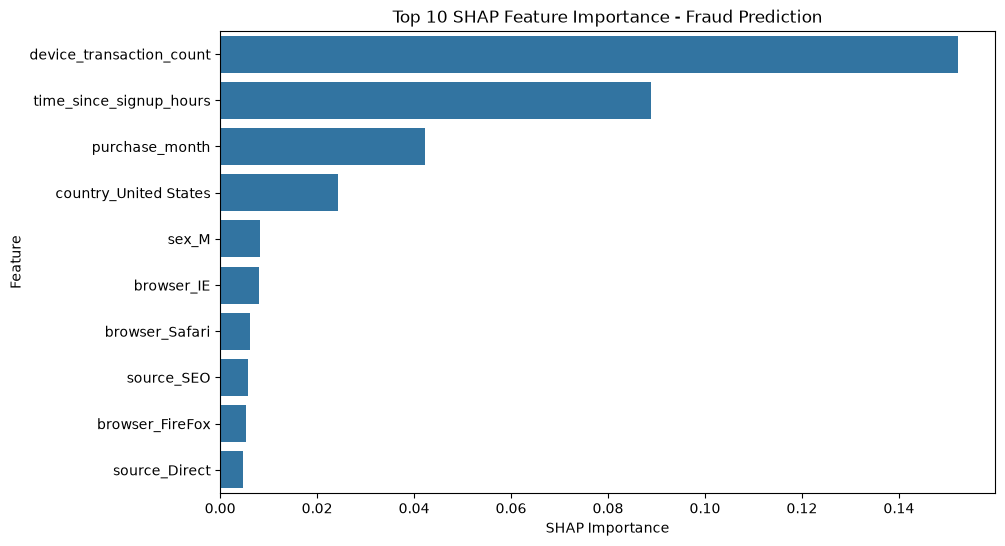

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=shap_importance.head(10),
    x="SHAP Importance",
    y="Feature"
)

plt.title(
    "Top 10 SHAP Feature Importance - Fraud Prediction"
)

plt.savefig(
    "../data/processed/shap_feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [46]:
shap_importance.to_csv(
    "../data/processed/shap_feature_importance.csv",
    index=False
)

## SHAP Interpretation and Business Insights

The SHAP analysis identified the main factors influencing fraud predictions.

### 1. Device Transaction Count

Device transaction count was the strongest fraud indicator. 
A high number of transactions associated with the same device increases the likelihood of fraudulent activity. This suggests that fraudsters may reuse devices or automated systems to perform multiple transactions.

### 2. Time Since Signup

Transactions occurring shortly after account creation showed higher fraud risk. Fraudulent users often create accounts and immediately perform purchases before detection systems can identify suspicious behavior.

### 3. Purchase Month

Transaction timing patterns contributed to fraud predictions. Certain months may contain increased fraudulent activity due to seasonal campaigns, promotions, or increased transaction volumes.

### 4. Country Location

Country information contributed to fraud detection. Transactions from certain countries showed different fraud patterns, highlighting the importance of geographic risk monitoring.

### 5. User Demographic Information

Gender-related features had lower influence compared with behavioral features. This indicates that transaction behavior is more valuable than demographic attributes for fraud detection.

## Business Recommendations

Based on the SHAP analysis, the following actions are recommended:

### 1. Implement Device-Based Risk Scoring

Transactions from devices with unusually high transaction frequency should receive additional verification steps such as OTP confirmation or manual review.

### 2. Add New Account Transaction Controls

Transactions occurring shortly after signup should have stricter verification rules because newly created accounts show increased fraud risk.

Example:
- Accounts created within a few hours before a purchase can receive higher fraud risk scores.

### 3. Introduce Geographic Risk Monitoring

Country-level fraud patterns should be monitored continuously. Transactions from high-risk regions or unusual locations should trigger additional authentication.

### 4. Use Behavioral Features as Primary Signals

The model shows that behavioral indicators outperform demographic attributes. Future fraud prevention systems should prioritize:
- transaction velocity,
- device activity,
- account age,
- purchasing patterns.